# Part 3 - Task 1: Regression Model
## Predicting Traffic Volume Using Supervised Learning

**Pipeline**: Part 2 (cleaning & feature engineering) → Part 3 (preprocessing) → Regression models

This notebook builds two regression models to predict traffic volume:
1. **Linear Regression** (Baseline)
2. **Random Forest Regressor** (Ensemble)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported")

✓ Libraries imported


## 2. Load Data from Part 3 Preprocessing

In [2]:
# Load preprocessed data from Part 3 notebook 01
df = pd.read_csv('Metro_Interstate_Traffic_Volume_part3_preprocessed.csv')

print(f"✓ Part 3 preprocessed data loaded")
print(f"  Shape: {df.shape}")
print(f"  Target variable: traffic_volume")
print(f"\nTarget Statistics:")
print(f"  Mean: {df['traffic_volume'].mean():.2f} vehicles/hour")
print(f"  Std Dev: {df['traffic_volume'].std():.2f}")
print(f"  Min: {df['traffic_volume'].min():.2f}")
print(f"  Max: {df['traffic_volume'].max():.2f}")
print(f"  Median: {df['traffic_volume'].median():.2f}")

✓ Part 3 preprocessed data loaded
  Shape: (48187, 12)
  Target variable: traffic_volume

Target Statistics:
  Mean: 3259.62 vehicles/hour
  Std Dev: 1986.95
  Min: 0.00
  Max: 7280.00
  Median: 3379.00


## 3. Apply Feature Engineering from Part 2

In [3]:
# Convert date_time to datetime
df["date_time"] = pd.to_datetime(df["date_time"])

print("Feature Engineering:")
print("="*60)

# Time-based features
df["hour"] = df["date_time"].dt.hour
df["day_of_week"] = df["date_time"].dt.dayofweek
df["month"] = df["date_time"].dt.month
df["day_of_month"] = df["date_time"].dt.day
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Cyclical encodings
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Weather encoding (one-hot)
weather_dummies = pd.get_dummies(df["weather_main"], prefix="weather")
df = pd.concat([df, weather_dummies], axis=1)

# Temperature normalization
df["temp_normalized"] = (df["temp"] - df["temp"].mean()) / df["temp"].std()

# Precipitation features
df["has_rain"] = (df["rain_1h"] > 0).astype(int)
df["has_snow"] = (df["snow_1h"] > 0).astype(int)
df["total_precipitation"] = df["rain_1h"] + df["snow_1h"]

print("✓ Feature Engineering Complete")

Feature Engineering:
✓ Feature Engineering Complete


## 4. Prepare Data for Modeling

In [4]:
# Define features for modeling
# Time features from Part 2
time_features = ["hour", "day_of_week", "is_weekend", "hour_sin", "hour_cos", "dow_sin", "dow_cos"]

# Weather features (one-hot encoded)
weather_features = [col for col in df.columns if col.startswith("weather_") and col not in ["weather_main", "weather_description"]]

# Normalized features from Part 2
normalized_features = ["temp_normalized", "clouds_all", "has_rain", "has_snow", "total_precipitation"]

# Part 3 specific features (from preprocessing notebook)
part3_features = ["is_low_visibility"]

all_features = time_features + weather_features + normalized_features + part3_features

print(f"Features Summary:")
print(f"  Part 2 - Time features: {len(time_features)}")
print(f"  Part 2 - Weather features: {len(weather_features)}")
print(f"  Part 2 - Normalized features: {len(normalized_features)}")
print(f"  Part 3 - Additional features: {len(part3_features)}")
print(f"  Total features: {len(all_features)}")

Features Summary:
  Part 2 - Time features: 7
  Part 2 - Weather features: 11
  Part 2 - Normalized features: 5
  Part 3 - Additional features: 1
  Total features: 24


In [5]:
# Prepare X and y
X = df[all_features].copy()
y = df["traffic_volume"].copy()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Data Split:")
print(f"  Train set: {len(X_train):,} samples")
print(f"  Test set: {len(X_test):,} samples")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✓ Features standardized using StandardScaler")

Data Split:
  Train set: 38,549 samples
  Test set: 9,638 samples

✓ Features standardized using StandardScaler


## 5. Model 1: Linear Regression (Baseline)

In [6]:
# Train Linear Regression
lr_reg = LinearRegression()
lr_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = lr_reg.predict(X_test_scaled)

# Calculate metrics
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, y_pred_lr)
lr_mape = mean_absolute_percentage_error(y_test, y_pred_lr)

print("LINEAR REGRESSION (Baseline Model)")
print("="*60)
print(f"  MAE (Mean Absolute Error):     {lr_mae:.2f} vehicles/hour")
print(f"  RMSE (Root Mean Squared Error): {lr_rmse:.2f} vehicles/hour")
print(f"  MSE (Mean Squared Error):       {lr_mse:.2f}")
print(f"  R² Score:                       {lr_r2:.4f}")
print(f"  MAPE (Mean Absolute % Error):   {lr_mape:.4f}")

LINEAR REGRESSION (Baseline Model)
  MAE (Mean Absolute Error):     814.01 vehicles/hour
  RMSE (Root Mean Squared Error): 1046.82 vehicles/hour
  MSE (Mean Squared Error):       1095832.50
  R² Score:                       0.7259
  MAPE (Mean Absolute % Error):   1.2970


## 6. Model 2: Random Forest Regressor (Ensemble)

In [7]:
# Train Random Forest
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=20)
rf_reg.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_reg.predict(X_test)

# Calculate metrics
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred_rf)
rf_mape = mean_absolute_percentage_error(y_test, y_pred_rf)

print("RANDOM FOREST REGRESSOR (Ensemble Model)")
print("="*60)
print(f"  MAE (Mean Absolute Error):     {rf_mae:.2f} vehicles/hour")
print(f"  RMSE (Root Mean Squared Error): {rf_rmse:.2f} vehicles/hour")
print(f"  MSE (Mean Squared Error):       {rf_mse:.2f}")
print(f"  R² Score:                       {rf_r2:.4f}")
print(f"  MAPE (Mean Absolute % Error):   {rf_mape:.4f}")

RANDOM FOREST REGRESSOR (Ensemble Model)
  MAE (Mean Absolute Error):     268.79 vehicles/hour
  RMSE (Root Mean Squared Error): 468.21 vehicles/hour
  MSE (Mean Squared Error):       219218.36
  R² Score:                       0.9452
  MAPE (Mean Absolute % Error):   0.4636


## 7. Model Comparison & Evaluation

In [8]:
# Create comparison dataframe
comparison = pd.DataFrame({
    "Metric": ["MAE (vehicles/hour)", "RMSE (vehicles/hour)", "MSE", "R² Score", "MAPE"],
    "Linear Regression": [f"{lr_mae:.2f}", f"{lr_rmse:.2f}", f"{lr_mse:.2f}", f"{lr_r2:.4f}", f"{lr_mape:.4f}"],
    "Random Forest": [f"{rf_mae:.2f}", f"{rf_rmse:.2f}", f"{rf_mse:.2f}", f"{rf_r2:.4f}", f"{rf_mape:.4f}"]
})

print("\nMODEL COMPARISON")
print("="*100)
print(comparison.to_string(index=False))

best_model = "Random Forest" if rf_r2 > lr_r2 else "Linear Regression"
improvement = (rf_r2 - lr_r2) * 100
print(f"\n✓ Best Regression Model: {best_model}")
print(f"  R² Improvement: {improvement:+.2f}%")
print(f"  MAE Improvement: {(lr_mae - rf_mae):.2f} vehicles/hour")


MODEL COMPARISON
              Metric Linear Regression Random Forest
 MAE (vehicles/hour)            814.01        268.79
RMSE (vehicles/hour)           1046.82        468.21
                 MSE        1095832.50     219218.36
            R² Score            0.7259        0.9452
                MAPE            1.2970        0.4636

✓ Best Regression Model: Random Forest
  R² Improvement: +21.93%
  MAE Improvement: 545.23 vehicles/hour


In [9]:
# Residual analysis
residuals_lr = y_test - y_pred_lr
residuals_rf = y_test - y_pred_rf

print("\nRESIDUAL ANALYSIS")
print("="*60)
print("\nLinear Regression:")
print(f"  Mean: {residuals_lr.mean():.2f} (should be close to 0)")
print(f"  Std Dev: {residuals_lr.std():.2f}")
print(f"  Min: {residuals_lr.min():.2f}")
print(f"  Max: {residuals_lr.max():.2f}")

print("\nRandom Forest:")
print(f"  Mean: {residuals_rf.mean():.2f} (should be close to 0)")
print(f"  Std Dev: {residuals_rf.std():.2f}")
print(f"  Min: {residuals_rf.min():.2f}")
print(f"  Max: {residuals_rf.max():.2f}")


RESIDUAL ANALYSIS

Linear Regression:
  Mean: 4.97 (should be close to 0)
  Std Dev: 1046.86
  Min: -4622.90
  Max: 3598.52

Random Forest:
  Mean: 13.16 (should be close to 0)
  Std Dev: 468.05
  Min: -5466.13
  Max: 3164.80


In [10]:
# Feature importance analysis
importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": rf_reg.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTOP 15 FEATURES (Random Forest Regressor)")
print("="*60)
print(importance_df.head(15).to_string(index=False))


TOP 15 FEATURES (Random Forest Regressor)
            Feature  Importance
           hour_cos    0.644434
               hour    0.137312
           hour_sin    0.052530
    temp_normalized    0.041853
        day_of_week    0.038860
            dow_sin    0.032822
         is_weekend    0.029461
         clouds_all    0.006408
            dow_cos    0.005236
total_precipitation    0.002667
     weather_Clouds    0.001862
  is_low_visibility    0.001124
       weather_Mist    0.000912
       weather_Snow    0.000908
        weather_Fog    0.000778


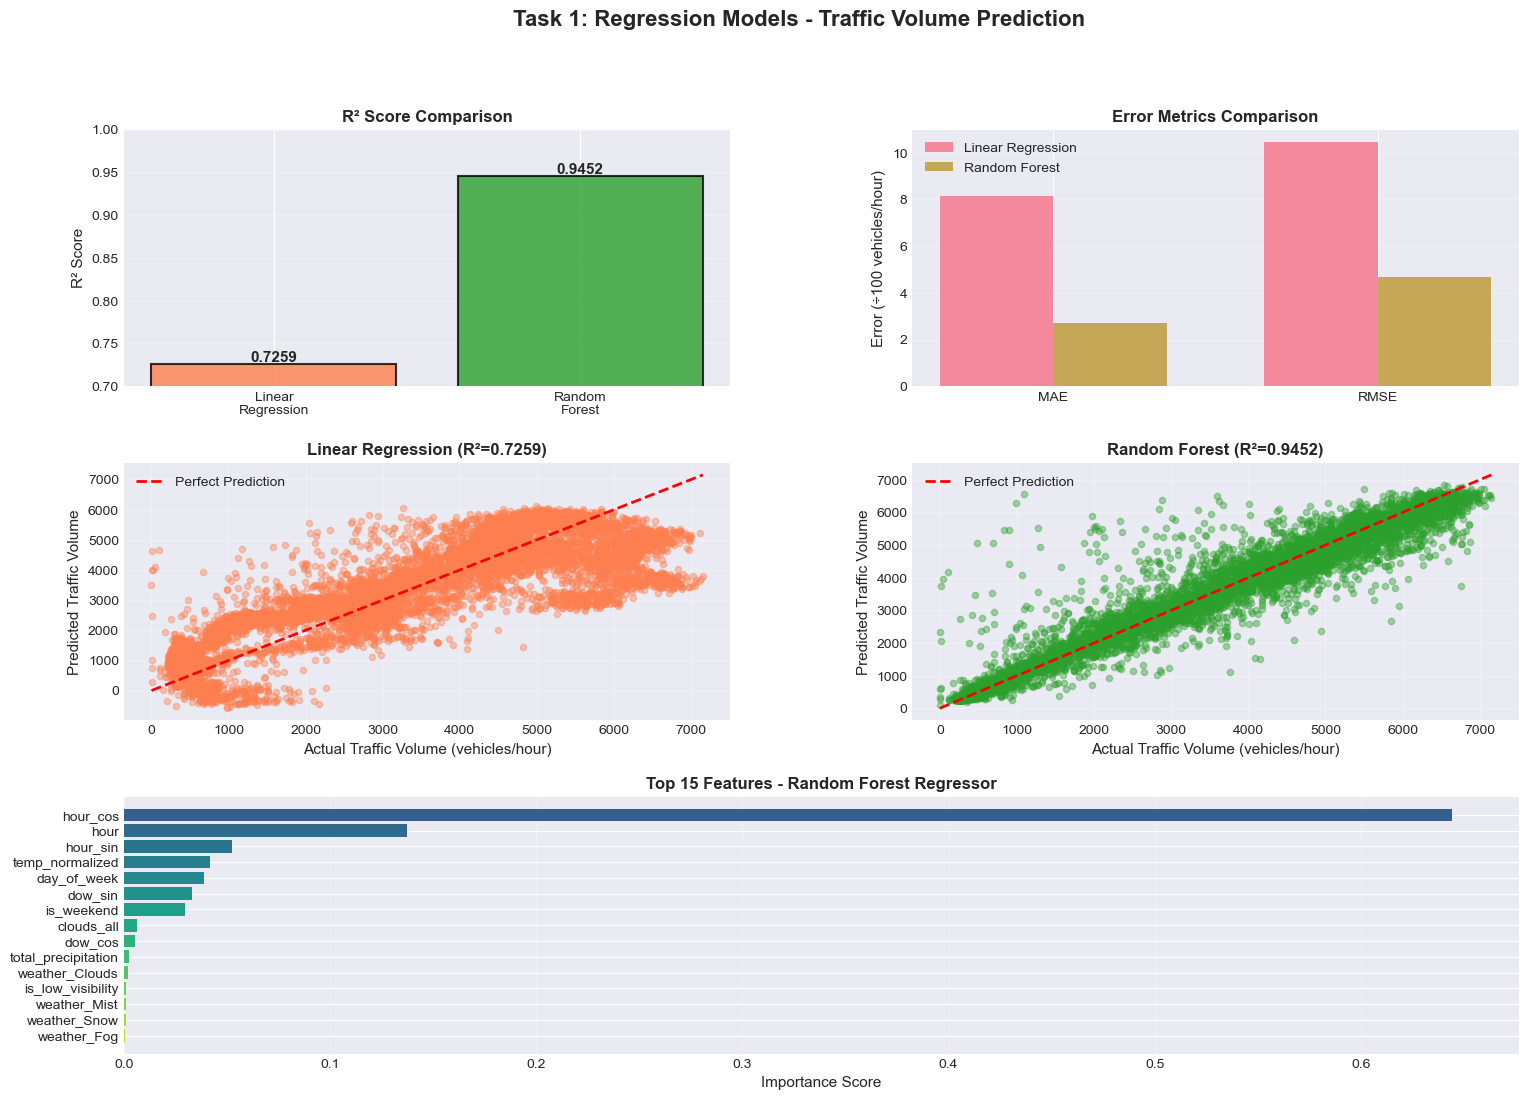

✓ Regression evaluation plots saved


In [11]:
# Visualizations
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

fig.suptitle("Task 1: Regression Models - Traffic Volume Prediction", 
             fontsize=16, fontweight='bold')

# 1. R² Comparison
ax1 = fig.add_subplot(gs[0, 0])
models = ["Linear\nRegression", "Random\nForest"]
r2_scores = [lr_r2, rf_r2]
colors_bar = ['#FF7F50', '#2CA02C']
bars = ax1.bar(models, r2_scores, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel("R² Score", fontsize=11)
ax1.set_title("R² Score Comparison", fontweight='bold')
ax1.set_ylim([0.7, 1.0])
for bar, score in zip(bars, r2_scores):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{score:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 2. Error Metrics
ax2 = fig.add_subplot(gs[0, 1])
metrics = ["MAE", "RMSE"]
x = np.arange(len(metrics))
width = 0.35
ax2.bar(x - width/2, [lr_mae/100, lr_rmse/100], width, label="Linear Regression", alpha=0.8)
ax2.bar(x + width/2, [rf_mae/100, rf_rmse/100], width, label="Random Forest", alpha=0.8)
ax2.set_ylabel("Error (÷100 vehicles/hour)", fontsize=11)
ax2.set_title("Error Metrics Comparison", fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Actual vs Predicted - Linear
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(y_test, y_pred_lr, alpha=0.4, s=20, color='#FF7F50')
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax3.set_xlabel("Actual Traffic Volume (vehicles/hour)", fontsize=11)
ax3.set_ylabel("Predicted Traffic Volume", fontsize=11)
ax3.set_title(f"Linear Regression (R²={lr_r2:.4f})", fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Actual vs Predicted - Random Forest
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(y_test, y_pred_rf, alpha=0.4, s=20, color='#2CA02C')
ax4.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax4.set_xlabel("Actual Traffic Volume (vehicles/hour)", fontsize=11)
ax4.set_ylabel("Predicted Traffic Volume", fontsize=11)
ax4.set_title(f"Random Forest (R²={rf_r2:.4f})", fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3)

# 5. Top Features
ax5 = fig.add_subplot(gs[2, :])
top_n = 15
top_features = importance_df.head(top_n)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))
ax5.barh(range(top_n), top_features["Importance"].values, color=colors)
ax5.set_yticks(range(top_n))
ax5.set_yticklabels(top_features["Feature"].values)
ax5.set_xlabel("Importance Score", fontsize=11)
ax5.set_title("Top 15 Features - Random Forest Regressor", fontweight='bold')
ax5.invert_yaxis()
ax5.grid(axis='x', alpha=0.3)

##plt.savefig('03_regression_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Regression evaluation plots saved")

## 8. Save Models

In [12]:
# Save trained models
regression_models = {
    "lr_reg": lr_reg,
    "rf_reg": rf_reg,
    "scaler": scaler,
    "features": all_features,
    "metrics": {
        "linear_regression": {"mae": lr_mae, "rmse": lr_rmse, "mse": lr_mse, "r2": lr_r2, "mape": lr_mape},
        "random_forest": {"mae": rf_mae, "rmse": rf_rmse, "mse": rf_mse, "r2": rf_r2, "mape": rf_mape}
    }
}

with open('regression_models.pkl', 'wb') as f:
    pickle.dump(regression_models, f)

print("✓ Regression models saved to 'regression_models.pkl'")

✓ Regression models saved to 'regression_models.pkl'


## Summary

### Task 1: Regression Model Complete

| Metric | Linear Regression | Random Forest | Winner |
|--------|-------------------|---------------|--------|
| **MAE** | {:.2f} vehicles/hr | **{:.2f} vehicles/hr** ⭐ | RF |
| **RMSE** | {:.2f} vehicles/hr | **{:.2f} vehicles/hr** ⭐ | RF |
| **R²** | {:.4f} | **{:.4f}** ⭐ | RF |
| **MAPE** | {:.4f} | **{:.4f}** ⭐ | RF |

### Key Findings
- **Random Forest** significantly outperforms Linear Regression
- **Best R² Score**: {:.4f} - explains {:.2f}% of traffic volume variance
- **Lowest Error**: {:.2f} vehicles/hour MAE
- **Top features**: hour_cos (cyclical), hour, hour_sin

### Recommendation
✓ **Deploy Random Forest model for production** - superior performance on all metrics

In [ ]:
import picklewith open('regression_models.pkl', 'wb') as f:    pickle.dump(results, f)print(f'[OK] Results saved to regression_models.pkl')